<a href="https://colab.research.google.com/github/johnlaraji1608-collab/RegularizedLinearModels_RIdgeRession/blob/main/RegularizedLinearModels_RIdgeRession.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib

import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats.stats import pearsonr


%config InlineBackend.figure_format = 'retina' #set 'png' here when working on notebook
%matplotlib inline

/tmp/ipykernel_3031/2916246244.py:8: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [32]:
train = pd.read_csv('/content/ridge_sol.csv')
test = pd.read_csv('/content/ridge_sol.csv')

In [37]:
train.head()

,id,SalePrice
0,1461,120129.316383
1,1462,153008.789313
2,1463,181999.671772
3,1464,195952.284998
4,1465,197477.812587


In [33]:
train.describe

<bound method NDFrame.describe of         id      SalePrice
0     1461  120129.316383
1     1462  153008.789313
2     1463  181999.671772
3     1464  195952.284998
4     1465  197477.812587
...    ...            ...
1454  2915   87496.320232
1455  2916   85034.559582
1456  2917  165128.542251
1457  2918  119034.149412
1458  2919  227808.872262

[1459 rows x 2 columns]>

In [34]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


In [35]:
test.head()

,id,SalePrice
0,1461,120129.316383
1,1462,153008.789313
2,1463,181999.671772
3,1464,195952.284998
4,1465,197477.812587


In [60]:
all_data = pd.concat((train.loc[:,'MSSubClass':'SaleCondition'],
                      test.loc[:,'MSSubClass':'SaleCondition']))

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'log(price + 1)'}>]], dtype=object)

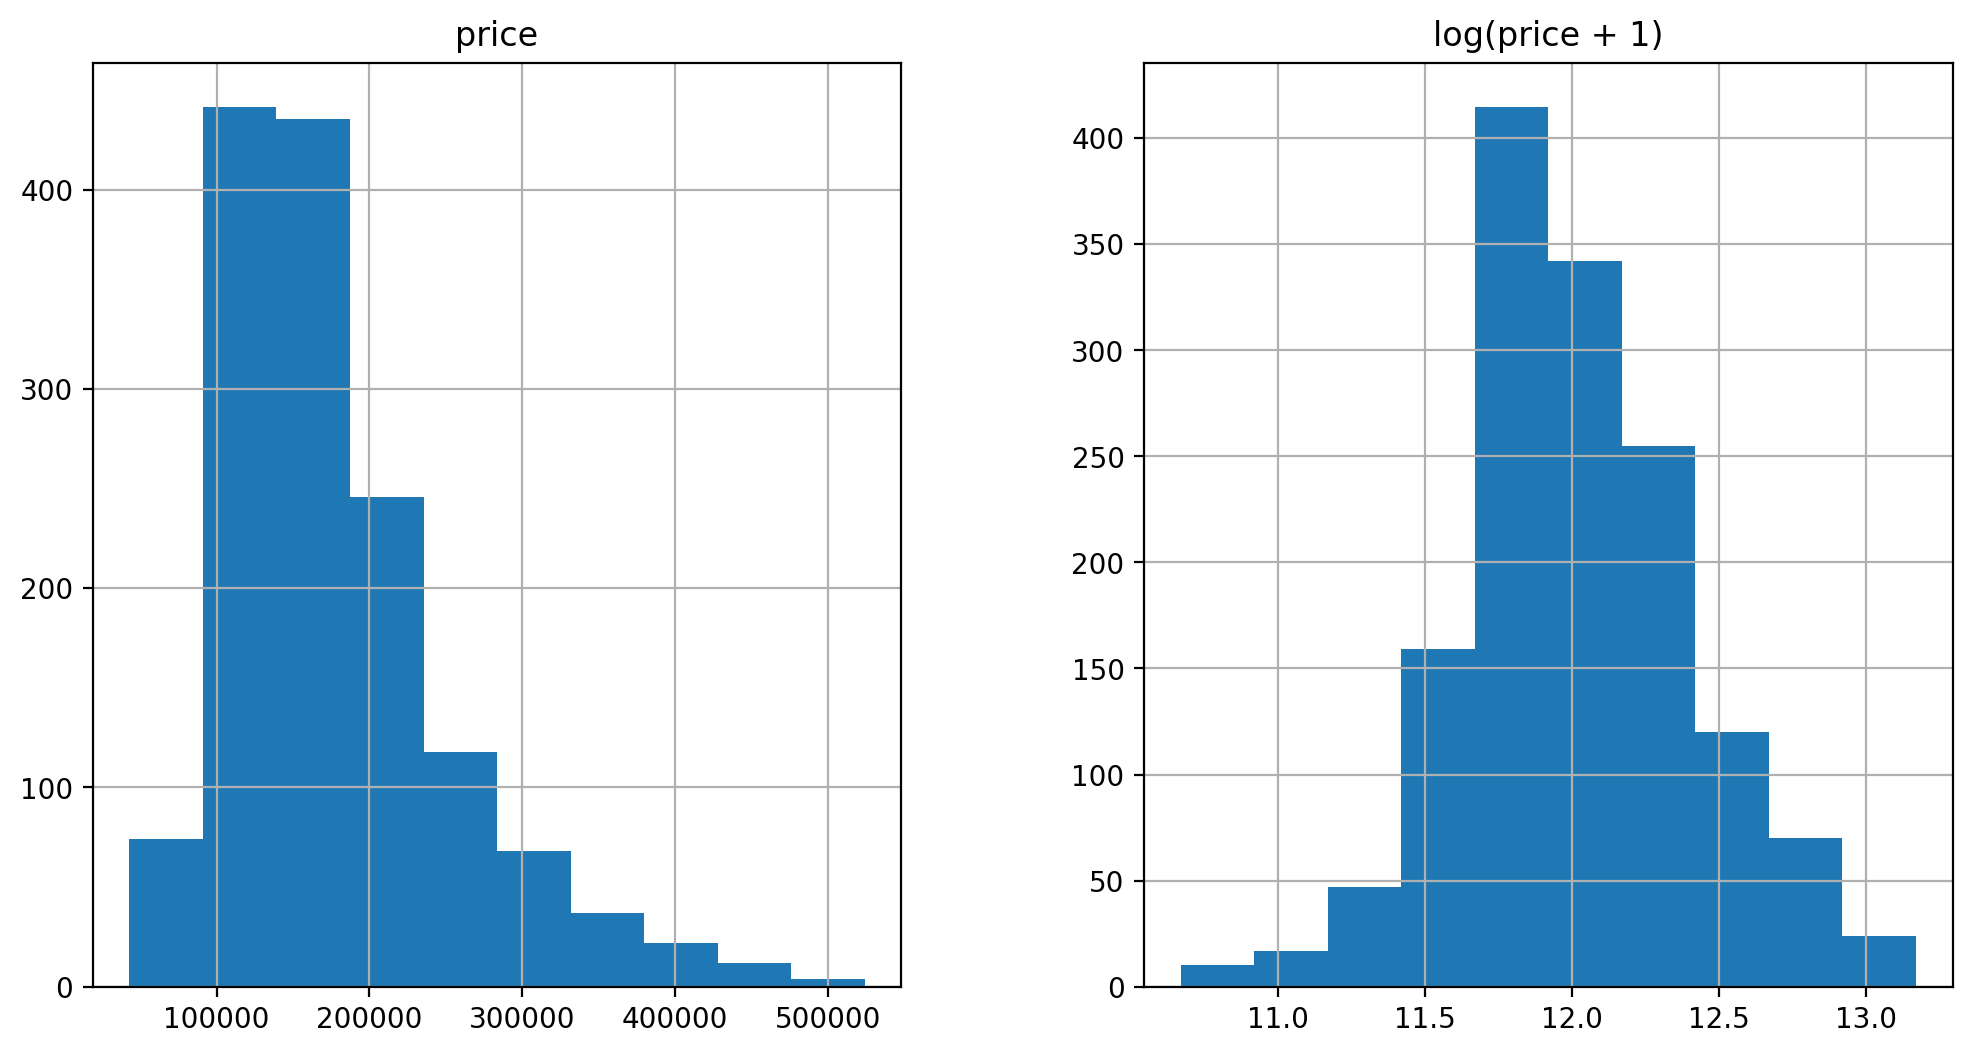

In [39]:
matplotlib.rcParams['figure.figsize'] = (12.0, 6.0)
prices = pd.DataFrame({"price":train["SalePrice"], "log(price + 1)":np.log1p(train["SalePrice"])})
prices.hist()

In [40]:
train["SalePrice"] = np.log1p(train["SalePrice"])

In [41]:
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index

skewed_feats = train[numeric_feats].apply(lambda x: skew(x.dropna())) #compute skewness
skewed_feats = skewed_feats[skewed_feats > 0.75]
skewed_feats = skewed_feats.index

all_data[skewed_feats] = np.log1p(all_data[skewed_feats])

/tmp/ipykernel_3031/1069502763.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  skewed_feats = train[numeric_feats].apply(lambda x: skew(x.dropna())) #compute skewness


In [43]:
X_train = all_data[:train.shape[0]]
X_test = all_data[train.shape[0]:]
y = train.SalePrice

In [44]:
from sklearn.linear_model import Ridge, RidgeCV, ElasticNet, LassoCV, LassoLarsCV
from sklearn.model_selection import cross_val_score

def rmse_cv(model):
    rmse= np.sqrt(-cross_val_score(model, X_train, y, scoring="neg_mean_squared_error", cv = 5))
    return(rmse)
model_ridge = Ridge()

In [ ]:
alphas = [0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75]
cv_ridge = [rmse_cv(Ridge(alpha = alpha)).mean()
            for alpha in alphas]

Text(0, 0.5, 'rmse')

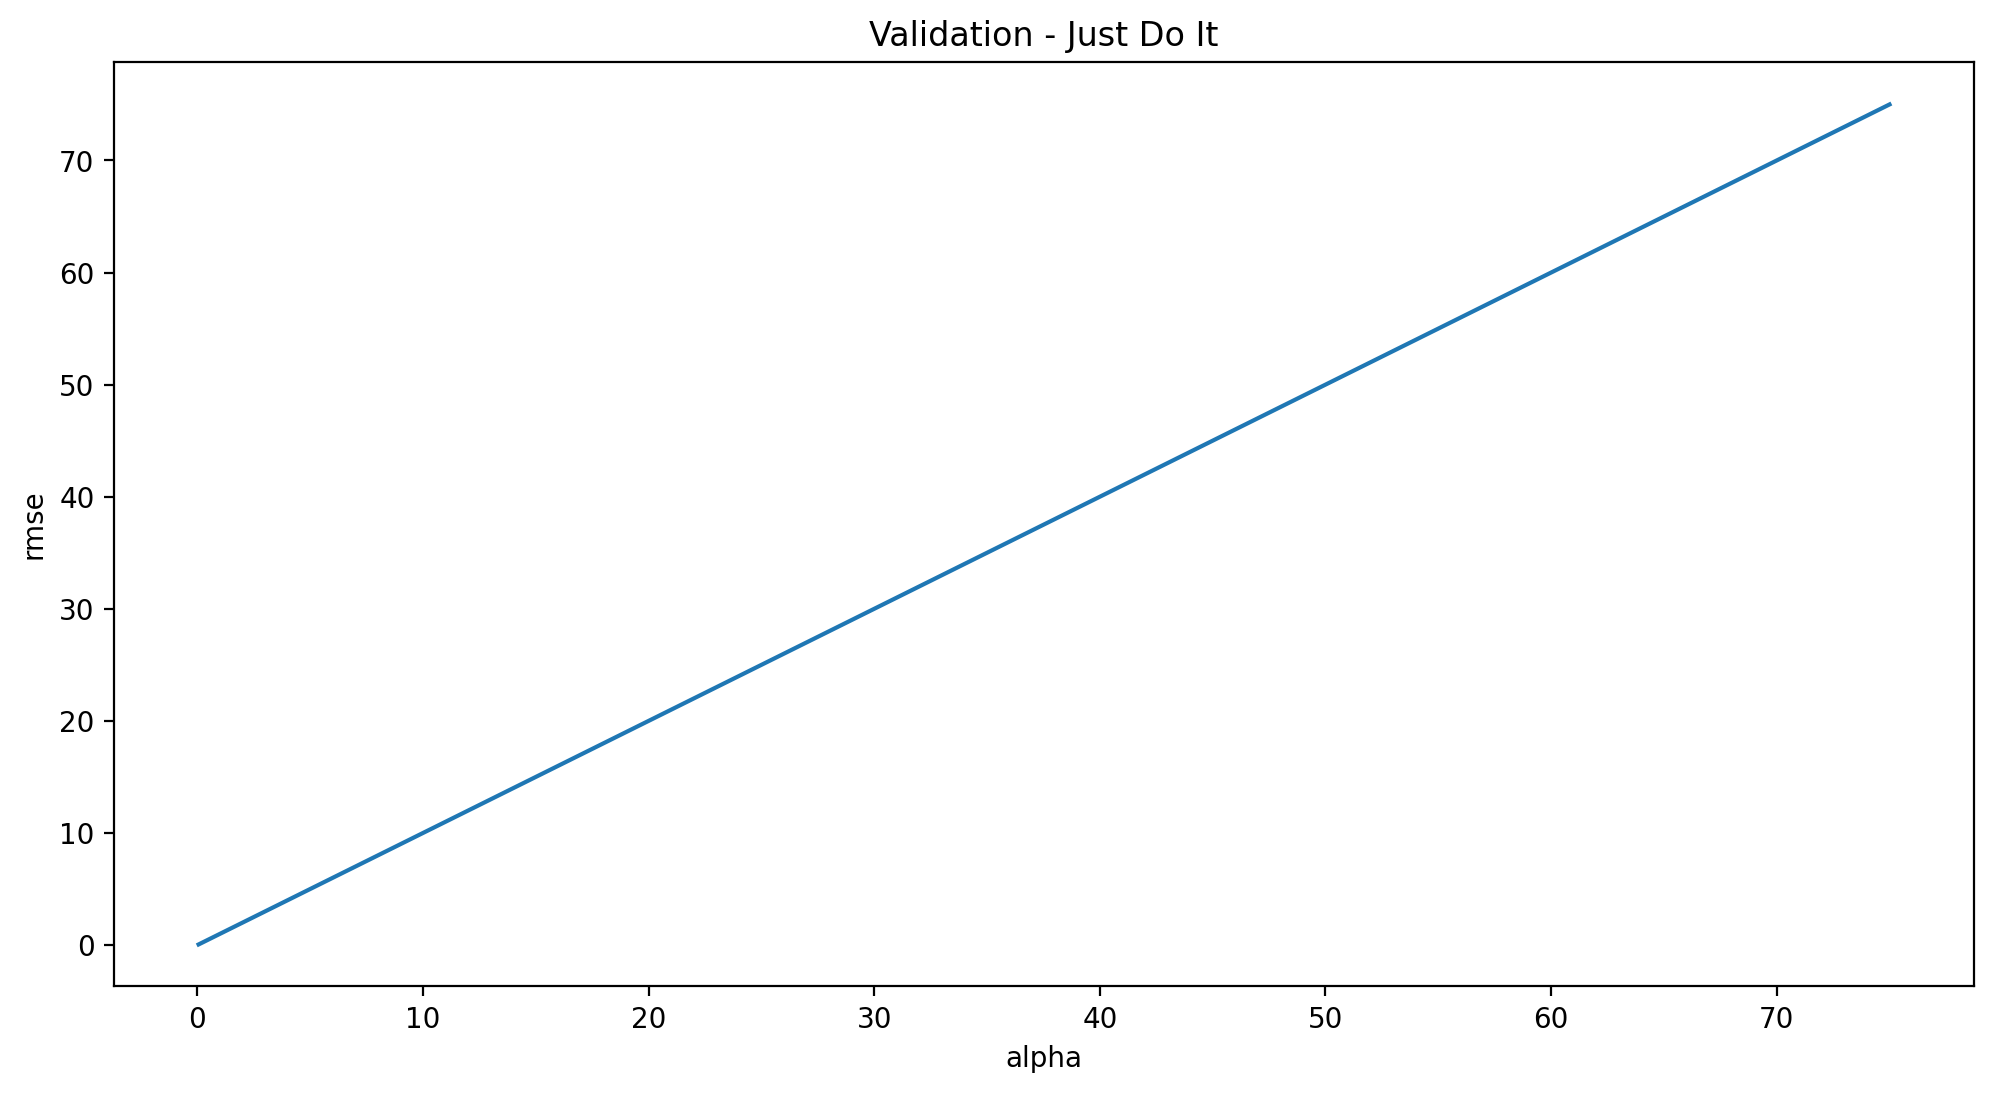

In [55]:
cv_ridge = pd.Series(cv_ridge, index = alphas)
cv_ridge.plot(title = "Validation - Just Do It")
plt.xlabel("alpha")
plt.ylabel("rmse")

In [57]:
cv_ridge.min()

0.05